In [2]:
!pip install leafmap

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import plotly.express as px
import geopandas as gpd
import pandas as pd 
from leafmap import maplibregl


In [5]:
# ispi_standoffs = pd.read_excel("data/ISPI - Standoffs in the Central Mediterranean (Crisi in mare).xlsx", header=1)
url = "https://docs.google.com/spreadsheets/d/1ahgkPp6NqMh3Dg63YHj8LVyaeW6-qHn2QQcRrKasJyM/export?format=xlsx&gid=0"
ispi_standoffs = pd.read_excel(url, header=1)


In [6]:
ispi_standoffs

,crisis number,ship,persons onboard,start date,end date,length of standoff,relocated (agreed),disembarked,where disembarked (Italy),nautical miles from Lampedusa,notes
0,1,Aquarius,629,2018-09-06 00:00:00,17/06/2018,9,0,Spagna,NaN,NaN,NaN
1,2,Diciotti,523,15/06/2018,19/06/2018,5,0,Italia,Pozzallo,130.0,NaN
2,3,Lifeline,234,21/06/2018,28/06/2018,8,220,Malta,NaN,NaN,NaN
3,4,Alexander Maersk,113,22/06/2018,26/06/2018,5,0,Italia,Pozzallo,130.0,NaN
4,5,Monte Sperone + Protector,447,13/07/2018,16/07/2018,4,270,Italia,Pozzallo,130.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
579,Governo Draghi,79,3.891626,5.936709,6,23.103448,185,186,NaN,NaN,NaN
580,Governo Meloni,426,10.775717,3.380841,4,36.602024,400,60,NaN,NaN,NaN
581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
582,Dati liberamente utilizzabili. Autori: Matteo ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ispi_standoffs['disembarked'].unique()

# TODO -> DA GESTIRE I DATI DOVE SONO SUDDIVISI IN PIÙ STATI (?)

array(['Spagna', 'Italia', 'Malta', 'Tunisia', '82 in Italia, 2 a Malta',
       '182 in Italia, 36 a Malta', 'Francia', '108 in Italy, 1 in Malta',
       '439 in Italy, 1 in Malta', 'Italia (2 Medevac a Malta)',
       'Italia (1 Medevac a Malta)', 'Italia ',
       'Italia (3 medevac Malta)', 'Italia (2 in Malta)',
       'Italia (1 in Malta)', nan,
       'median # migrants rescued per mission', 70, 148, 186, 60],
      dtype=object)

In [8]:
ispi_standoffs['where disembarked (Italy)'].unique()

array([nan, 'Pozzallo', 'Catania', 'Lampedusa', 'Augusta', 'Messina',
       'Taranto', 'Palermo', 'Porto Empedocle', 'Olbia', 'Trapani',
       'Pozallo', 'Salerno', 'Livorno', 'Reggio Calabria', 'Tolone',
       'Bari', 'Gioia Tauro', 'Ravenna', 'Ancona', 'La Spezia',
       'Marina di Carrara', 'Napoli', 'Civitavecchia', 'Ortona',
       'Brindisi', 'Vibo Valentia', 'Marina di Carrara + Livorno',
       'Genova', 'Crotone', 'Civitavecchia / Genova',
       'Ancona (23 in Catania 16/03)', 'Bari (111 in Lampedusa)',
       'Genova (73 in Lampedusa)', 'Pozzallo (50 in Lampedusa)',
       'Ravenna (90 in Lampedusa)', 'Pozzallo (32 in Lampedusa)',
       'Genova (40 in Olbia)', 'Marina di Carrara (10 in Trapani)',
       'Trapani (3 in Lampedusa)', 'Napoli (44 in Siracusa)',
       'Crotone (147 in Lampedusa)', 'Savona', 'Ortona (9 in Lampedusa)',
       'Taranto (53 in Lampedusa)', 'La Spezia (4 medevac Sicilia)',
       'La Spezia (31 in Pantelleria)', 'Brindisi (3 medevac)'],
      dt

In [9]:
!pip install geopy


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# -> TEST geocode
cols = ['city']
names = [('Roma'),('Trento'),('Genova'),('Trieste'),('Venezia')]
cities = gpd.GeoDataFrame(names,columns=cols)
geo_cities = gpd.tools.geocode(cities.city, provider="arcgis")

In [11]:
cities_ispi = ispi_standoffs[ispi_standoffs['where disembarked (Italy)'].notna()]
cities_ispi

,crisis number,ship,persons onboard,start date,end date,length of standoff,relocated (agreed),disembarked,where disembarked (Italy),nautical miles from Lampedusa,notes
1,2,Diciotti,523,15/06/2018,19/06/2018,5,0,Italia,Pozzallo,130.0,NaN
3,4,Alexander Maersk,113,22/06/2018,26/06/2018,5,0,Italia,Pozzallo,130.0,NaN
4,5,Monte Sperone + Protector,447,13/07/2018,16/07/2018,4,270,Italia,Pozzallo,130.0,NaN
6,7,Diciotti,177,14/08/2018,25/08/2018,12,50,Italia,Catania,210.0,NaN
12,13,Sea-Watch 3,47,19/01/2019,31/01/2019,13,32,Italia,Catania,210.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
566,567,Aurora SAR,42,13/12/2025,14/12/2025,2,0,Italia,Augusta,185.0,NaN
567,568,Life Support,113,13/12/2025,17/12/2025,5,0,Italia,Napoli,350.0,NaN
568,569,Solidaire,39,25/12/2025,29/12/2025,5,0,Italia,Livorno,510.0,NaN
569,570,Ocean Viking,33,31/12/2025,2026-05-01 00:00:00,6,0,Italia,Savona,570.0,NaN


In [12]:
cities_ispi['where disembarked (Italy)'].unique()

array(['Pozzallo', 'Catania', 'Lampedusa', 'Augusta', 'Messina',
       'Taranto', 'Palermo', 'Porto Empedocle', 'Olbia', 'Trapani',
       'Pozallo', 'Salerno', 'Livorno', 'Reggio Calabria', 'Tolone',
       'Bari', 'Gioia Tauro', 'Ravenna', 'Ancona', 'La Spezia',
       'Marina di Carrara', 'Napoli', 'Civitavecchia', 'Ortona',
       'Brindisi', 'Vibo Valentia', 'Marina di Carrara + Livorno',
       'Genova', 'Crotone', 'Civitavecchia / Genova',
       'Ancona (23 in Catania 16/03)', 'Bari (111 in Lampedusa)',
       'Genova (73 in Lampedusa)', 'Pozzallo (50 in Lampedusa)',
       'Ravenna (90 in Lampedusa)', 'Pozzallo (32 in Lampedusa)',
       'Genova (40 in Olbia)', 'Marina di Carrara (10 in Trapani)',
       'Trapani (3 in Lampedusa)', 'Napoli (44 in Siracusa)',
       'Crotone (147 in Lampedusa)', 'Savona', 'Ortona (9 in Lampedusa)',
       'Taranto (53 in Lampedusa)', 'La Spezia (4 medevac Sicilia)',
       'La Spezia (31 in Pantelleria)', 'Brindisi (3 medevac)'],
      dtype=o

In [ ]:
col = "where disembarked (Italy)"
# -> solo nomi principali, nessuna sotto specifica per più POS per singolo record
cities_ispi[col] = (
    cities_ispi[col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*\(.*\)", "", regex=True)
    # normalizzazioni specifiche
    .str.replace(r".*Civitavecchia / Genova.*", "Civitavecchia", regex=True)
    .str.replace(r".*Pozallo.*", "Pozzallo", regex=True)
    .str.replace(
        r".*Marina\s+di\s+Carrara\s*\+\s*Livorno.*",
        "Marina di Carrara",
        regex=True
    )
    .str.strip()
)

ispi_standoffs


In [18]:
print(len(cities_ispi['where disembarked (Italy)'].unique()))
cities_ispi['where disembarked (Italy)'].unique()


28


array(['Pozzallo', 'Catania', 'Lampedusa', 'Augusta', 'Messina',
       'Taranto', 'Palermo', 'Porto Empedocle', 'Olbia', 'Trapani',
       'Salerno', 'Livorno', 'Reggio Calabria', 'Tolone', 'Bari',
       'Gioia Tauro', 'Ravenna', 'Ancona', 'La Spezia',
       'Marina di Carrara', 'Napoli', 'Civitavecchia', 'Ortona',
       'Brindisi', 'Vibo Valentia', 'Genova', 'Crotone', 'Savona'],
      dtype=object)

In [27]:
cities_ispi

,crisis number,ship,persons onboard,start date,end date,length of standoff,relocated (agreed),disembarked,where disembarked (Italy),nautical miles from Lampedusa,notes
1,2,Diciotti,523,15/06/2018,19/06/2018,5,0,Italia,Pozzallo,130.0,NaN
3,4,Alexander Maersk,113,22/06/2018,26/06/2018,5,0,Italia,Pozzallo,130.0,NaN
4,5,Monte Sperone + Protector,447,13/07/2018,16/07/2018,4,270,Italia,Pozzallo,130.0,NaN
6,7,Diciotti,177,14/08/2018,25/08/2018,12,50,Italia,Catania,210.0,NaN
12,13,Sea-Watch 3,47,19/01/2019,31/01/2019,13,32,Italia,Catania,210.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
566,567,Aurora SAR,42,13/12/2025,14/12/2025,2,0,Italia,Augusta,185.0,NaN
567,568,Life Support,113,13/12/2025,17/12/2025,5,0,Italia,Napoli,350.0,NaN
568,569,Solidaire,39,25/12/2025,29/12/2025,5,0,Italia,Livorno,510.0,NaN
569,570,Ocean Viking,33,31/12/2025,2026-05-01 00:00:00,6,0,Italia,Savona,570.0,NaN


In [ ]:
# geo_cities_ispi = gpd.tools.geocode(cities_ispi['where disembarked (Italy)'].unique(), provider="arcgis")
# -> Assegnare geometrie località POS 
places = (
    cities_ispi['where disembarked (Italy)']
    .dropna()
    .unique()
    .tolist()
)

rows = []

for place in places:
    try:
        g = gpd.tools.geocode(str(place)+ ', Italia', provider="arcgis")

        if len(g) > 0:
            rows.append({
                "where disembarked (Italy)": place,
                "geometry": g.geometry.iloc[0],
                "address": g.address.iloc[0]
            })
        else:
            rows.append({
                "where disembarked (Italy)": place,
                "geometry": None,
                "address": None
            })

    except Exception:
        rows.append({
            "where disembarked (Italy)": place,
            "geometry": None,
            "address": None
        })

geo_cities_ispi = gpd.GeoDataFrame(
    rows,
    geometry="geometry",
    crs="EPSG:4326"
)

geo_cities_ispi.head()

,where disembarked (Italy),geometry,address
0,Pozzallo,POINT (14.8457 36.72605),"Pozzallo, Ragusa"
1,Catania,POINT (15.08783 37.50248),Catania
2,Lampedusa,POINT (12.60982 35.50112),"Lampedusa, Lampedusa e Linosa, Agrigento"
3,Augusta,POINT (15.219 37.23375),"Augusta, Siracusa"
4,Messina,POINT (15.55552 38.19233),Messina


In [16]:
geo_cities_ispi

,where disembarked (Italy),geometry,address
0,Pozzallo,POINT (14.8457 36.72605),"Pozzallo, Ragusa"
1,Catania,POINT (15.08783 37.50248),Catania
2,Lampedusa,POINT (12.60982 35.50112),"Lampedusa, Lampedusa e Linosa, Agrigento"
3,Augusta,POINT (15.219 37.23375),"Augusta, Siracusa"
4,Messina,POINT (15.55552 38.19233),Messina
5,Taranto,POINT (17.24006 40.46922),Taranto
6,Palermo,POINT (13.36147 38.11566),Palermo
7,Porto Empedocle,POINT (13.5269 37.28652),"Porto Empedocle, Agrigento"
8,Olbia,POINT (9.48685 40.92251),"Olbia, Sassari"
9,Trapani,POINT (12.51463 38.01859),Trapani


In [19]:
geo_cities_ispi.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

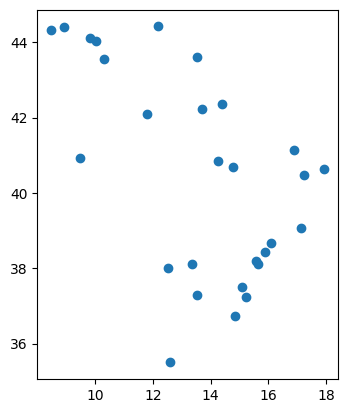

In [20]:
type(geo_cities_ispi)
geo_cities_ispi.plot()

In [28]:
ispi_standoff_gpd = cities_ispi.merge(geo_cities_ispi, on="where disembarked (Italy)", how='left')

ispi_standoff_gpd = gpd.GeoDataFrame(ispi_standoff_gpd, geometry=ispi_standoff_gpd.geometry)

In [29]:
ispi_standoff_gpd[ispi_standoff_gpd['where disembarked (Italy)'].notna()]['disembarked'].unique()

array(['Italia', '82 in Italia, 2 a Malta', '182 in Italia, 36 a Malta',
       'Francia', '108 in Italy, 1 in Malta', '439 in Italy, 1 in Malta',
       'Italia (2 Medevac a Malta)', 'Italia (1 Medevac a Malta)',
       'Italia ', 'Italia (3 medevac Malta)', 'Italia (2 in Malta)',
       'Italia (1 in Malta)'], dtype=object)

In [30]:
ispi_standoff_gpd_it = ispi_standoff_gpd[ispi_standoff_gpd['where disembarked (Italy)'].notna()]
ispi_standoff_gpd_it.to_crs(epsg=4326)
print(ispi_standoff_gpd_it.crs)
type(ispi_standoff_gpd_it)

EPSG:4326


geopandas.geodataframe.GeoDataFrame

In [31]:
ispi_standoff_gpd_it

,crisis number,ship,persons onboard,start date,end date,length of standoff,relocated (agreed),disembarked,where disembarked (Italy),nautical miles from Lampedusa,notes,geometry,address
0,2,Diciotti,523,15/06/2018,19/06/2018,5,0,Italia,Pozzallo,130.0,NaN,POINT (14.8457 36.72605),"Pozzallo, Ragusa"
1,4,Alexander Maersk,113,22/06/2018,26/06/2018,5,0,Italia,Pozzallo,130.0,NaN,POINT (14.8457 36.72605),"Pozzallo, Ragusa"
2,5,Monte Sperone + Protector,447,13/07/2018,16/07/2018,4,270,Italia,Pozzallo,130.0,NaN,POINT (14.8457 36.72605),"Pozzallo, Ragusa"
3,7,Diciotti,177,14/08/2018,25/08/2018,12,50,Italia,Catania,210.0,NaN,POINT (15.08783 37.50248),Catania
4,13,Sea-Watch 3,47,19/01/2019,31/01/2019,13,32,Italia,Catania,210.0,NaN,POINT (15.08783 37.50248),Catania
...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,567,Aurora SAR,42,13/12/2025,14/12/2025,2,0,Italia,Augusta,185.0,NaN,POINT (15.219 37.23375),"Augusta, Siracusa"
550,568,Life Support,113,13/12/2025,17/12/2025,5,0,Italia,Napoli,350.0,NaN,POINT (14.25254 40.83998),Napoli
551,569,Solidaire,39,25/12/2025,29/12/2025,5,0,Italia,Livorno,510.0,NaN,POINT (10.30784 43.55189),Livorno
552,570,Ocean Viking,33,31/12/2025,2026-05-01 00:00:00,6,0,Italia,Savona,570.0,NaN,POINT (8.47725 44.31107),Savona


In [32]:
ispi_standoff_gpd_it.to_file( 
    "ispi_standoff_it.gpkg",
    layer="ITALY",
    driver="GPKG")